#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [18]:
# put all import statements here
import numpy as np
from gaussxw import gaussxw
import matplotlib.pyplot as plt

## Gaussian Quadrature 1 (22 pts)

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ a) Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

b) Repeat the evaluation with 2𝑁 points and evaluate the error.  

c) Compare these results with your results for both the trapezoidal and Simpson’s rules


In [14]:
# part a

#defining the function
def f(x):
    return np.sin(x)/np.log(x)

#limits and points
a = 1.1 
b = 10.1
N=10


xk,wk = gaussxw(N,a,b)

s = 0.0
for i in range(N):
    s += wk[i]*f(xk[i])

print(s)




2.7929415637242574


In [16]:
# part b

N = 20

xk,wk = gaussxw(N,a,b)

s_2 = 0.0
for i in range(N):
    s_2 += wk[i]*f(xk[i])

print(s_2)

GQ_err = s_2 - s
print(GQ_err)



2.84805880772841
0.05511724400415252


### part c

the error for GQ is larger than both the trapeziodal and simpson method. This is surprising as I though this would be a more accurate way to determine a integral. 



## Gaussian Quadrature 2 (22 pts)

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


a) First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

c) Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


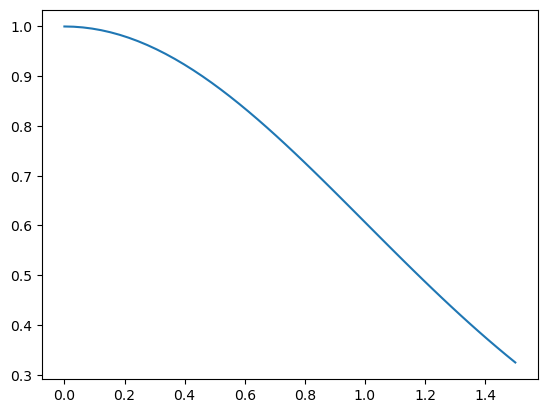

In [ ]:
def f_2(x):
    return np.exp((-x**2)/2)

x = np.linspace(0,1.5,50)
y = f_2(x)

plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")

plt.show()

Yes this function is smooth, as it shows a decreasing frunction from 1 down the end just above 0.3. We should expect an okay result from the GQ method. It is only okay because it has just 2 sample points which is low. So, we should expect some noticable error. 

In [24]:
a = 0.0
b = 1.5 
N = 2

x, w = gaussxw(N)
print(x)
print(w)

xk = 0.5*(b-a)*x+0.5*(b+a)
wk = 0.5*(b-a)*w
print(xk)
print(wk)

s = 0.0
for k in range(N):
    s += wk[k]*f_2(xk[k])

print(s)

[ 0.57735027 -0.57735027]
[1. 1.]
[1.1830127 0.3169873]
[0.75 0.75]
1.0857790801898561


I used a lot of the code from class, just changing some varibles and the user def func. 

In [29]:
N = 4

x, w = gaussxw(N)
print(x)
print(w)

xk = 0.5*(b-a)*x+0.5*(b+a)
wk = 0.5*(b-a)*w
print(xk)
print(wk)

s_new = 0.0
for k in range(N):
    s_new += wk[k]*f_2(xk[k])

print(s_new)
print(s_new-s)

[ 0.86113631  0.33998104 -0.33998104 -0.86113631]
[0.34785485 0.65214515 0.65214515 0.34785485]
[1.39585223 1.00498578 0.49501422 0.10414777]
[0.26089113 0.48910887 0.48910887 0.26089113]
1.0858542826593234
7.52024694672393e-05


doubling N to 4 was able to hit the desired error. 

## Gaussian Quadrature 3 (22 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$. Do so in the via the following steps: 

a)  First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Start with $N=5$ sample points & use a `while` loop to continue doubling $N$ until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 


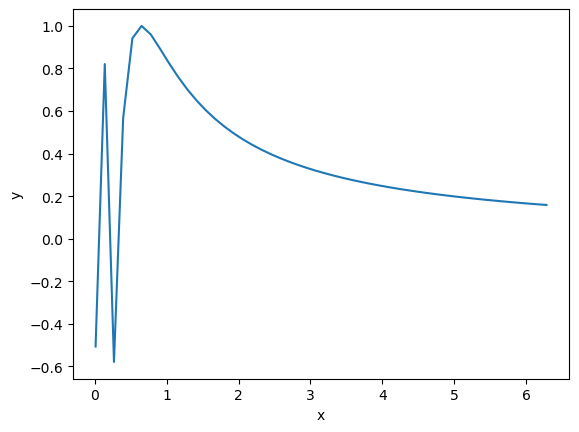

In [ ]:
#function
def f_3(x):
    return np.sin(1/x)

#array of steps from the given bounds
x = np.linspace(0.01, 2*np.pi,50)
y = f_3(x)

#printing the plot
plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()



This function is not smooth, we can see some sharp edges and not unifrom movement which indicates that the graph is not very smooth. Similar to above we expect the GQ method to be moderatley accurate with a noticable error. 

In [ ]:
#variables 
N = 4
a = 0.01
b = 2*np.pi

#tolerance
tol = 1e-5

#first integral
x, w = gaussxw(N)

xk = 0.5*(b-a)*x+0.5*(b+a)
wk = 0.5*(b-a)*w

s = 0.0
for k in range(N):
    s += wk[k]*f_3(xk[k])

print(s)


#we want to double the steps
N_1 = 2*N
x, w = gaussxw(N_1)
xk = 0.5*(b-a)*x+0.5*(b+a)
wk = 0.5*(b-a)*w

#second integral
s_2 = 0.0
for k in range(N_1):
    s_2 += wk[k]*f_3(xk[k])

print(s_2)


#while loop, this says that while the difference between the computed integrals is larger than the tolerance keep doubling N
while np.abs(s_2 -s) > tol:
    N = N_1
    s = s_2

    N_1 = 2*N



print(N_1)






2.4653232078959975
2.7072914091673965
16
0.0


the error does get a little smaller every time we double N until we get the desired error and the related steps. 

## Infinite integrals (22 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

#### Step 2: Define the function to use in the next step for integration

#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

## Multiple integrals (22 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/$\text{m}^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you'll need to swithch the cell to markdown and then you can use some of my latex coding from the cell above this)

#### Step 2: Define the function to use in the next step for integration

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$